# 🧠 Deep Learning Practical 6 — Generative Models
## VAE · GAN · CGAN · DCGAN on Fashion-MNIST & EMNIST
**Sardar Vallabhbhai National Institute of Technology, Surat**  
Department of Artificial Intelligence — AI302

---
This notebook implements all four generative architectures as required by the assignment,
along with evaluation metrics, data augmentation experiments, and GAN variant analysis.

## 1. Setup and Imports

In [1]:
# Install required libraries
!pip install torchmetrics[image] pytorch-fid scikit-image umap-learn tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.7 MB/s eta 0:00:00


In [2]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import cycle

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image

from tqdm import tqdm
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Output directories
WORK_DIR     = '/kaggle/working'
DATA_DIR     = '/kaggle/working/data'
GEN_DIR      = '/kaggle/working/generated'
MODEL_DIR    = '/kaggle/working/models'

for d in [DATA_DIR, GEN_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
print('Directories created. Ready.')

Using device: cuda
Directories created. Ready.


## 2. Dataset Loading and Visualization

In [3]:
# ----- Transforms -----
# Normalize to [-1,1] for GAN variants; [0,1] for VAE (sigmoid output)
transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # -> [-1, 1]
])

transform_vae = transforms.Compose([
    transforms.ToTensor()  # -> [0, 1] for BCE loss
])

# ----- FashionMNIST -----
fmnist_train_gan = datasets.FashionMNIST(DATA_DIR, train=True,  download=True, transform=transform_gan)
fmnist_test_gan  = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=transform_gan)
fmnist_train_vae = datasets.FashionMNIST(DATA_DIR, train=True,  download=True, transform=transform_vae)
fmnist_test_vae  = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=transform_vae)

# ----- EMNIST (balanced) -----
emnist_train_gan = datasets.EMNIST(DATA_DIR, split='balanced', train=True,  download=True, transform=transform_gan)
emnist_test_gan  = datasets.EMNIST(DATA_DIR, split='balanced', train=False, download=True, transform=transform_gan)
emnist_train_vae = datasets.EMNIST(DATA_DIR, split='balanced', train=True,  download=True, transform=transform_vae)
emnist_test_vae  = datasets.EMNIST(DATA_DIR, split='balanced', train=False, download=True, transform=transform_vae)

# Dataset info
FMNIST_CLASSES = 10
EMNIST_CLASSES = 47

FMNIST_LABELS = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'FashionMNIST  -> Train: {len(fmnist_train_gan)}, Test: {len(fmnist_test_gan)}')
print(f'EMNIST (bal.) -> Train: {len(emnist_train_gan)}, Test: {len(emnist_test_gan)}')

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 268kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.9MB/s]
100%|██████████| 562M/562M [00:02<00:00, 226MB/s]  


FashionMNIST  -> Train: 60000, Test: 10000
EMNIST (bal.) -> Train: 112800, Test: 18800


In [4]:
# ----- DataLoaders -----
BATCH_SIZE = 128

def make_loader(dataset, shuffle=True):
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

loaders = {
    'fmnist_gan': make_loader(fmnist_train_gan),
    'fmnist_vae': make_loader(fmnist_train_vae),
    'emnist_gan': make_loader(emnist_train_gan),
    'emnist_vae': make_loader(emnist_train_vae),
}

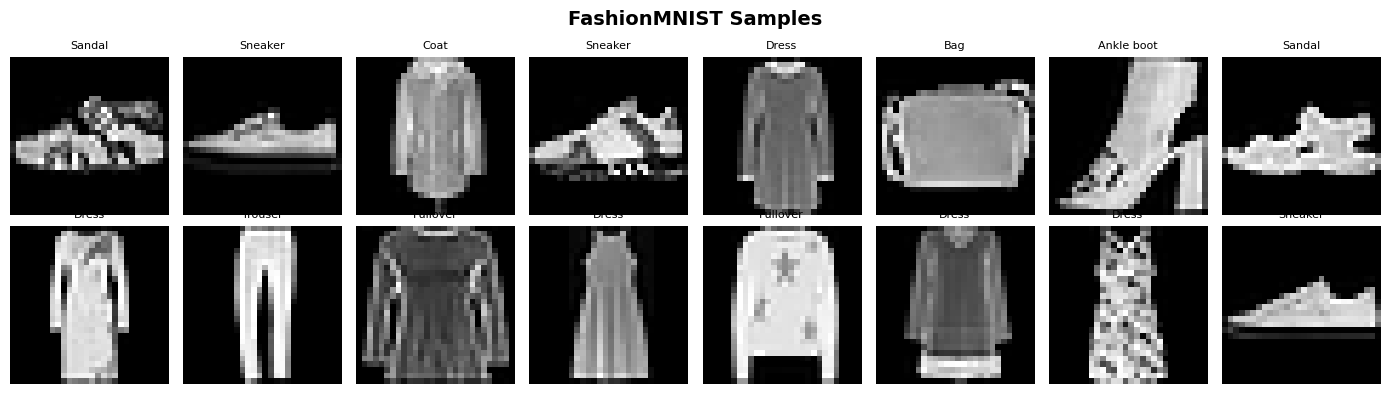

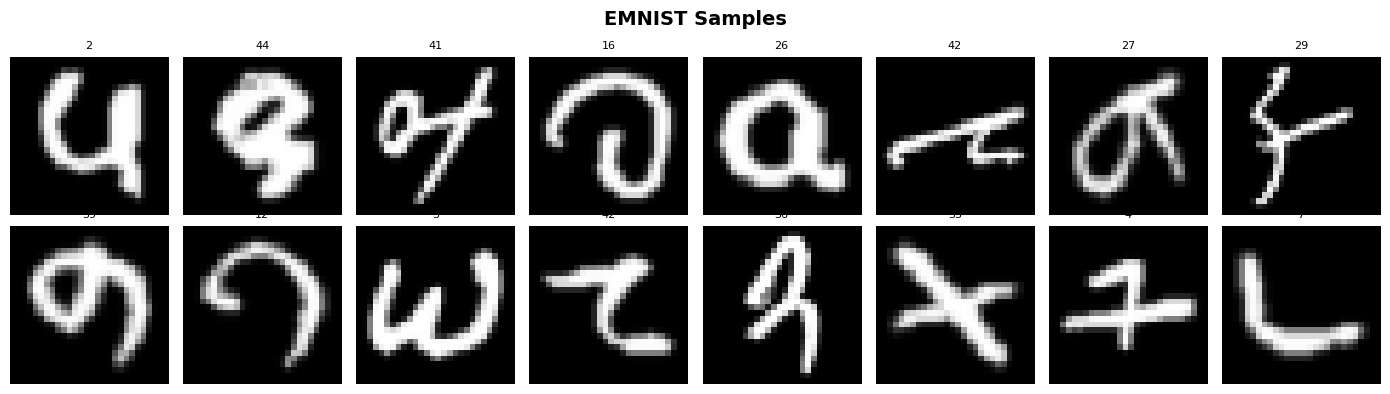

In [5]:
# ----- Visualize samples -----
def show_samples(dataset, title, n=16, labels=None):
    loader = DataLoader(dataset, batch_size=n, shuffle=True)
    imgs, lbls = next(iter(loader))
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ttl = str(lbls[i].item())
        if labels:
            ttl = labels[lbls[i].item()]
        ax.set_title(ttl, fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{GEN_DIR}/{title.replace(" ","_")}_samples.png', dpi=100)
    plt.show()

show_samples(fmnist_train_vae, 'FashionMNIST Samples', labels=FMNIST_LABELS)
show_samples(emnist_train_vae, 'EMNIST Samples')

## 3. Variational Autoencoder (VAE)

In [11]:
# ============================================================
#  VAE Architecture
# ============================================================

class VAEEncoder(nn.Module):
    """Encoder: image -> (mu, logvar)"""
    def __init__(self, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        h = self.net(x.view(x.size(0), -1))
        return self.fc_mu(h), self.fc_logvar(h)


class VAEDecoder(nn.Module):
    """Decoder: z -> reconstructed image"""
    def __init__(self, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 784),        nn.Sigmoid()  # [0,1]
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder  = VAEEncoder(latent_dim)
        self.decoder  = VAEDecoder(latent_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        """z = mu + eps * exp(0.5*logvar), eps ~ N(0,I)"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        recon      = self.decoder(z)
        return recon, mu, logvar

    def sample(self, n=16):
        """Sample z ~ N(0,I) and decode"""
        with torch.no_grad():
            z = torch.randn(n, self.latent_dim).to(DEVICE)
            return self.decoder(z)


def vae_loss(recon, x, mu, logvar, kl_weight=1.0):
    """ELBO = E[log p(x|z)] - KL(q||p)"""
    bce = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
    kl  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return bce + kl_weight * kl, bce, kl


print('VAE architecture defined.')

VAE architecture defined.


In [12]:
# ============================================================
#  VAE Training Function
# ============================================================

def train_vae(dataset_name='fmnist', latent_dim=32, epochs=30, kl_anneal_epochs=10):
    loader = loaders[f'{dataset_name}_vae']
    model  = VAE(latent_dim).to(DEVICE)
    opt    = optim.Adam(model.parameters(), lr=1e-3)

    history = {'loss': [], 'bce': [], 'kl': []}
    best_loss = float('inf')

    for epoch in range(1, epochs + 1):
        # KL annealing: linearly warm up from 0 to 1 over first kl_anneal_epochs
        kl_weight = min(1.0, epoch / kl_anneal_epochs)

        model.train()
        epoch_loss = epoch_bce = epoch_kl = 0.0

        for imgs, _ in tqdm(loader, desc=f'[VAE-{dataset_name} z={latent_dim}] Ep {epoch}/{epochs}', leave=False):
            imgs = imgs.to(DEVICE)
            opt.zero_grad()
            recon, mu, logvar = model(imgs)
            loss, bce, kl = vae_loss(recon, imgs, mu, logvar, kl_weight)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
            epoch_bce  += bce.item()
            epoch_kl   += kl.item()

        n = len(loader)
        history['loss'].append(epoch_loss / n)
        history['bce'].append(epoch_bce / n)
        history['kl'].append(epoch_kl / n)

        # Early stopping + checkpoint
        if history['loss'][-1] < best_loss:
            best_loss = history['loss'][-1]
            torch.save(model.state_dict(),
                       f'{MODEL_DIR}/vae_{dataset_name}_z{latent_dim}.pt')

        if epoch % 10 == 0:
            print(f'Ep {epoch:3d} | Loss {history["loss"][-1]:.2f} '
                  f'| BCE {history["bce"][-1]:.2f} | KL {history["kl"][-1]:.2f}')

    return model, history

In [14]:
# ============================================================
#  VAE Visualization Helpers
# ============================================================

def show_reconstructions(model, loader, title, n=8):
    """Show original vs reconstructed images."""
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)
    with torch.no_grad():
        recon, _, _ = model(imgs)
    comparison = torch.cat([imgs.cpu(), recon.cpu()], dim=0)
    grid = make_grid(comparison, nrow=n, normalize=True, value_range=(0,1))
    plt.figure(figsize=(14, 3))
    plt.imshow(grid.permute(1,2,0).numpy(), cmap='gray')
    plt.title(f'{title}  (top: original, bottom: reconstructed)')
    plt.axis('off')
    plt.savefig(f'{GEN_DIR}/vae_{title}_recon.png', dpi=100, bbox_inches='tight')
    plt.show()


def latent_interpolation(model, loader, title, steps=10):
    """Interpolate between two images in latent space."""
    model.eval()
    imgs, _ = next(iter(loader))
    x1, x2 = imgs[0:1].to(DEVICE), imgs[1:2].to(DEVICE)
    with torch.no_grad():
        mu1, _ = model.encoder(x1)
        mu2, _ = model.encoder(x2)
        alphas = torch.linspace(0, 1, steps).to(DEVICE)
        interp = [model.decoder(mu1*(1-a) + mu2*a) for a in alphas]
        interp = torch.cat(interp, dim=0)
    grid = make_grid(interp.cpu(), nrow=steps, normalize=True, value_range=(0,1))
    plt.figure(figsize=(14, 2))
    plt.imshow(grid.permute(1,2,0).numpy(), cmap='gray')
    plt.title(f'Latent Space Interpolation — {title}')
    plt.axis('off')
    plt.savefig(f'{GEN_DIR}/vae_{title}_interpolation.png', dpi=100, bbox_inches='tight')
    plt.show()


def random_samples_vae(model, title, n=64):
    """Sample z ~ N(0,I) and decode."""
    samples = model.sample(n).cpu()
    grid = make_grid(samples, nrow=8, normalize=True, value_range=(0,1))
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1,2,0).numpy(), cmap='gray')
    plt.title(f'VAE Random Samples — {title}')
    plt.axis('off')
    plt.savefig(f'{GEN_DIR}/vae_{title}_samples.png', dpi=100, bbox_inches='tight')
    plt.show()


def plot_vae_loss(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history['loss'], label='Total Loss')
    plt.plot(history['bce'],  label='BCE')
    plt.plot(history['kl'],   label='KL')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(f'VAE Training Loss — {title}')
    plt.legend(); plt.grid(True)
    plt.savefig(f'{GEN_DIR}/vae_{title}_loss.png', dpi=100, bbox_inches='tight')
    plt.show()


print('VAE helpers ready.')

VAE helpers ready.


=== Training VAE on FashionMNIST ===


Ep  10 | Loss 239.77 | BCE 224.80 | KL 14.97


Ep  20 | Loss 237.19 | BCE 222.43 | KL 14.76


Ep  30 | Loss 236.10 | BCE 221.32 | KL 14.78


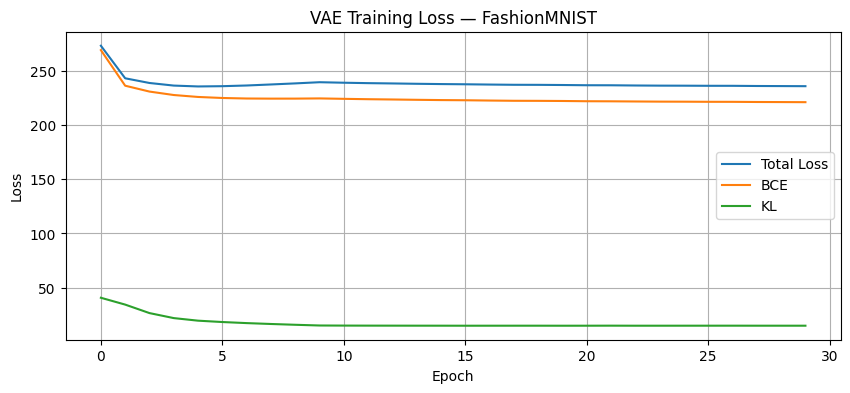

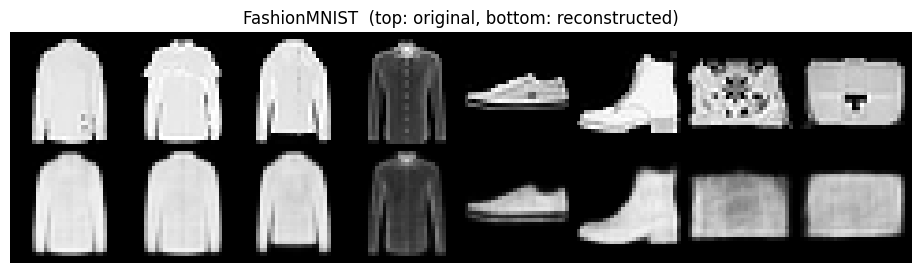

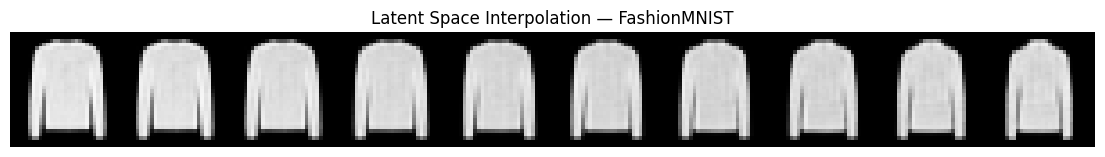

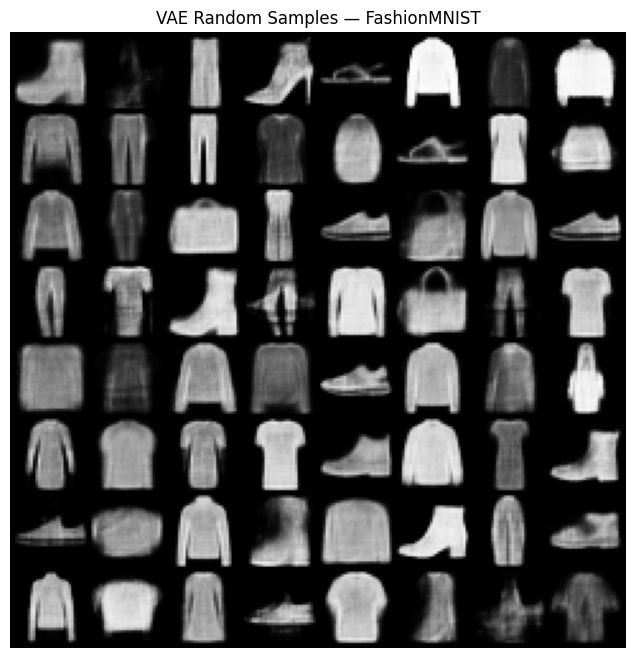

In [9]:
# ============================================================
#  Train VAE — FashionMNIST
# ============================================================
print('=== Training VAE on FashionMNIST ===')
vae_fmnist, hist_fmnist = train_vae('fmnist', latent_dim=32, epochs=30)
plot_vae_loss(hist_fmnist, 'FashionMNIST')
show_reconstructions(vae_fmnist, loaders['fmnist_vae'], 'FashionMNIST')
latent_interpolation(vae_fmnist, loaders['fmnist_vae'], 'FashionMNIST')
random_samples_vae(vae_fmnist, 'FashionMNIST')

=== Training VAE on EMNIST ===


Ep  10 | Loss 150.19 | BCE 118.89 | KL 31.31


Ep  20 | Loss 147.54 | BCE 117.29 | KL 30.25


Ep  30 | Loss 146.35 | BCE 116.42 | KL 29.93


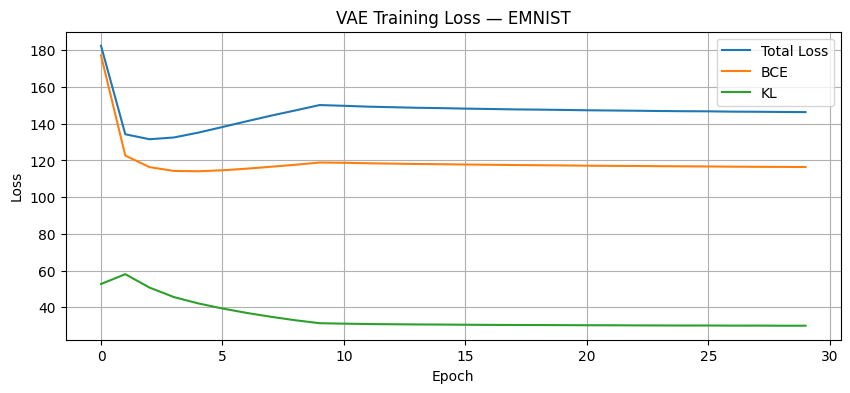

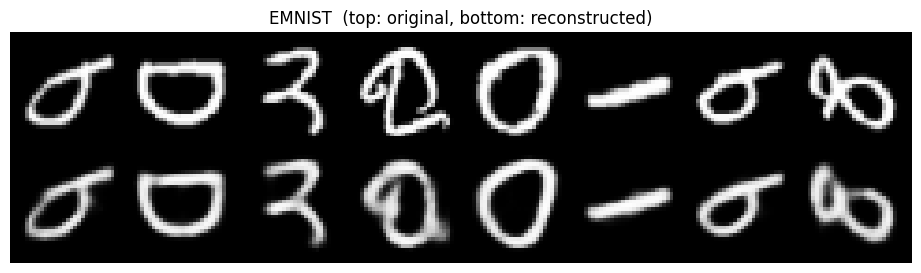

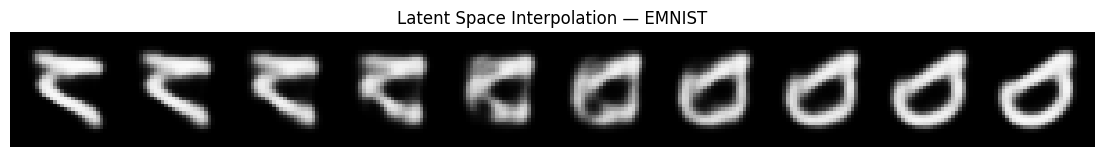

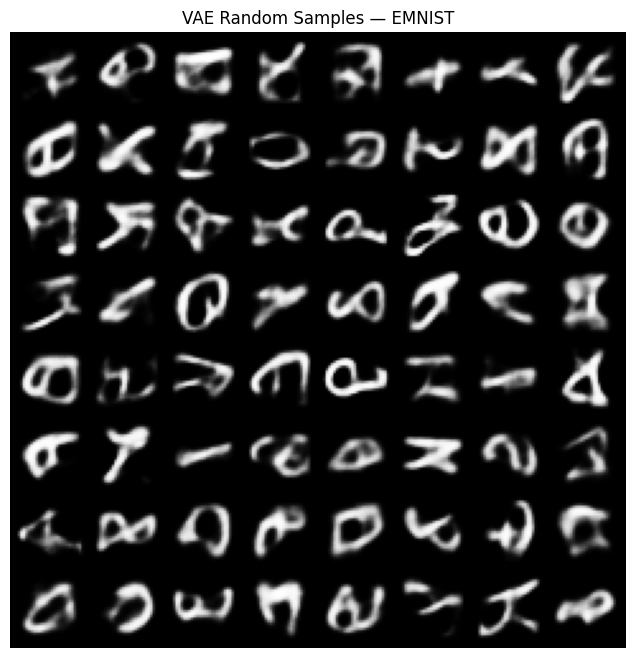

In [10]:
# ============================================================
#  Train VAE — EMNIST
# ============================================================
print('=== Training VAE on EMNIST ===')
vae_emnist, hist_emnist = train_vae('emnist', latent_dim=32, epochs=30)
plot_vae_loss(hist_emnist, 'EMNIST')
show_reconstructions(vae_emnist, loaders['emnist_vae'], 'EMNIST')
latent_interpolation(vae_emnist, loaders['emnist_vae'], 'EMNIST')
random_samples_vae(vae_emnist, 'EMNIST')

=== Latent Dimension Study ===
--- z = 8 ---


Ep  10 | Loss 239.25 | BCE 225.22 | KL 14.03


Ep  20 | Loss 237.11 | BCE 223.16 | KL 13.95


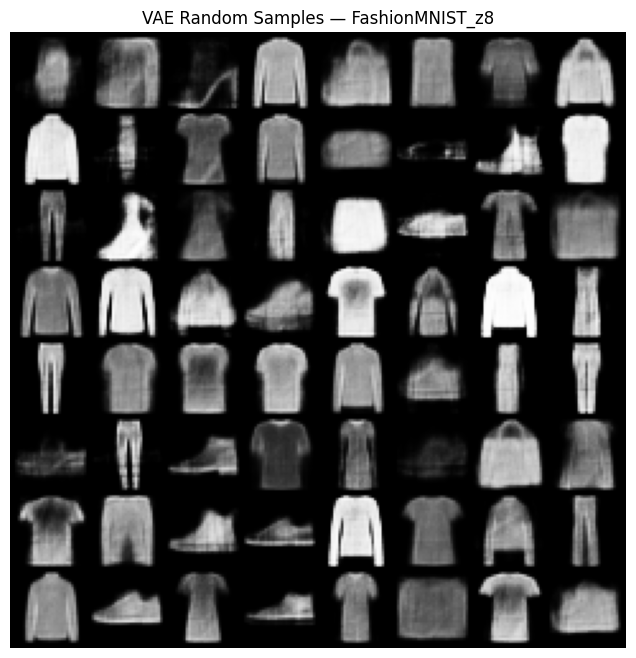

--- z = 32 ---


Ep  10 | Loss 239.79 | BCE 225.24 | KL 14.55


Ep  20 | Loss 237.20 | BCE 222.77 | KL 14.43


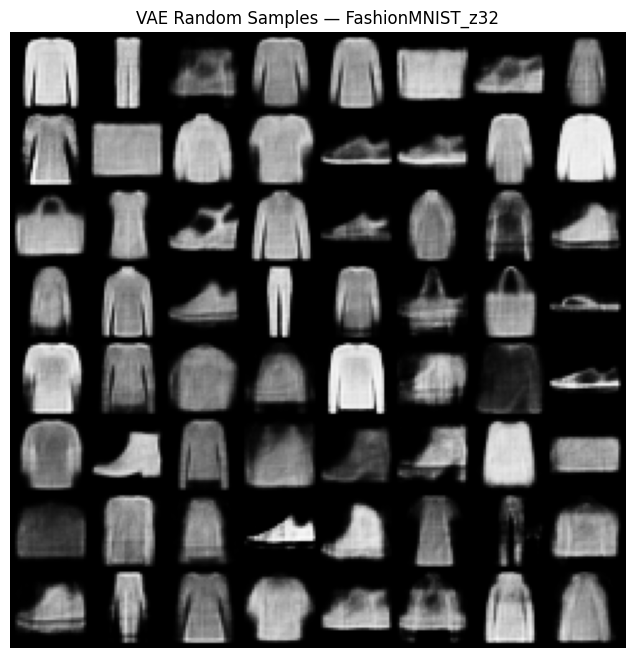

--- z = 128 ---


Ep  10 | Loss 240.74 | BCE 226.02 | KL 14.73


Ep  20 | Loss 237.97 | BCE 223.45 | KL 14.52


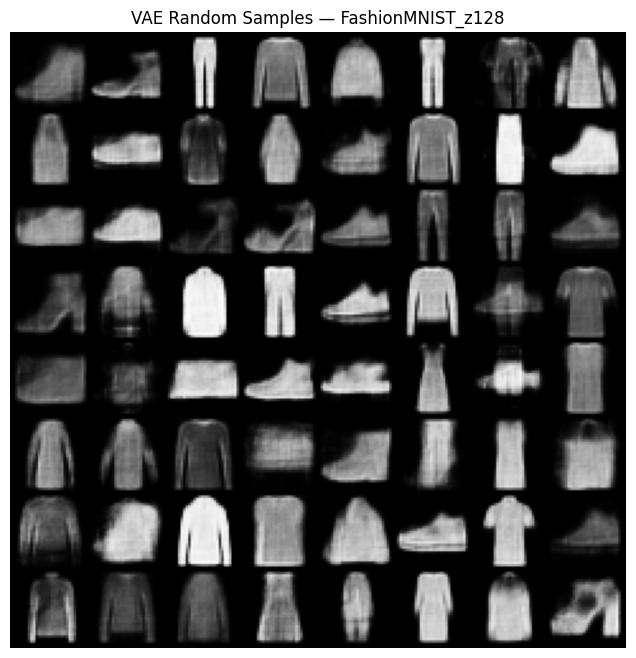

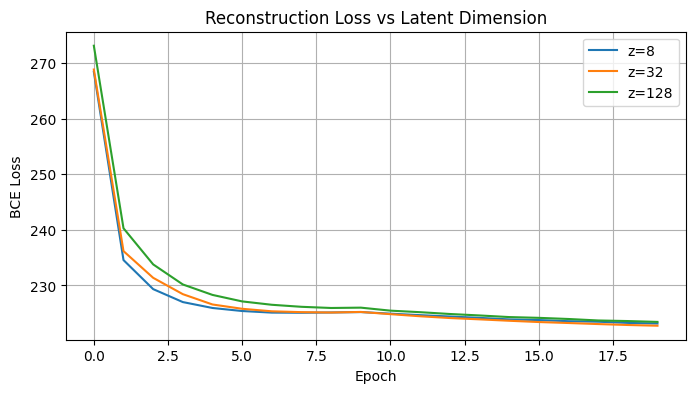

In [15]:
# ============================================================
#  Latent Dimension Study: z in {8, 32, 128}
# ============================================================
print('=== Latent Dimension Study ===')
latent_dims = [8, 32, 128]
ld_results  = {}

for z in latent_dims:
    print(f'--- z = {z} ---')
    m, h = train_vae('fmnist', latent_dim=z, epochs=20)
    ld_results[z] = {'model': m, 'history': h, 'final_loss': h['loss'][-1]}
    random_samples_vae(m, f'FashionMNIST_z{z}')

# Compare final reconstruction loss
plt.figure(figsize=(8,4))
for z in latent_dims:
    plt.plot(ld_results[z]['history']['bce'], label=f'z={z}')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.title('Reconstruction Loss vs Latent Dimension')
plt.legend(); plt.grid(True)
plt.savefig(f'{GEN_DIR}/vae_latent_dim_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

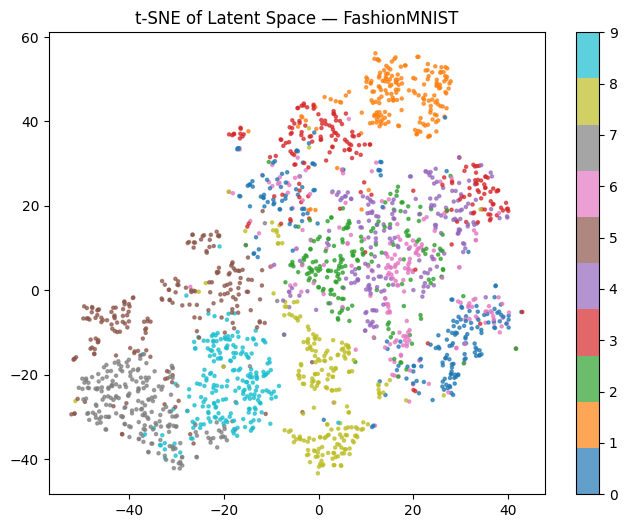

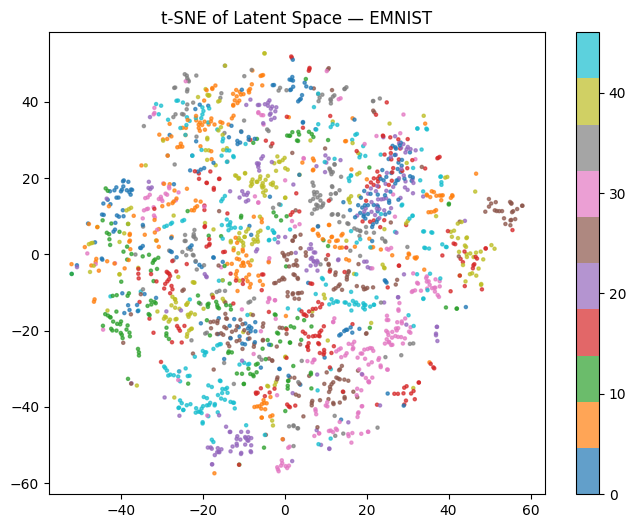

In [19]:
# ============================================================
#  t-SNE of Latent Space
# ============================================================

def plot_tsne_latent(model, loader, title, n_samples=2000):
    model.eval()
    zs, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            mu, _ = model.encoder(imgs.to(DEVICE))
            zs.append(mu.cpu().numpy())
            labels.append(lbls.numpy())
            if sum(len(z) for z in zs) >= n_samples:
                break
    Z = np.concatenate(zs)[:n_samples]
    L = np.concatenate(labels)[:n_samples]
    tsne = TSNE(n_components=2, random_state=42)
    Z2d = tsne.fit_transform(Z)
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(Z2d[:,0], Z2d[:,1], c=L, cmap='tab10', s=5, alpha=0.7)
    plt.colorbar(scatter)
    plt.title(f't-SNE of Latent Space — {title}')
    plt.savefig(f'{GEN_DIR}/vae_{title}_tsne.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_tsne_latent(vae_fmnist, loaders['fmnist_vae'], 'FashionMNIST')
plot_tsne_latent(vae_emnist, loaders['emnist_vae'], 'EMNIST')

## 4. Vanilla GAN Implementation

In [20]:
# ============================================================
#  Vanilla GAN — Generator and Discriminator
# ============================================================

class GANGenerator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.noise_dim = noise_dim
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.LeakyReLU(0.2), nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2), nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2), nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),
            nn.Tanh()  # output in [-1,1]
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

    def sample_noise(self, n):
        return torch.randn(n, self.noise_dim, device=DEVICE)


class GANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


print('Vanilla GAN defined.')

Vanilla GAN defined.


In [31]:
# ============================================================
#  GAN Training Function (supports non-saturating variant)
# ============================================================

def train_gan(dataset_name='fmnist', noise_dim=100, epochs=50,
              non_saturating=False, label='gan'):
    loader = loaders[f'{dataset_name}_gan']
    G = GANGenerator(noise_dim).to(DEVICE)
    D = GANDiscriminator().to(DEVICE)

    opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    history = {'G_loss': [], 'D_loss': []}
    best_G_loss = float('inf')

    # Fixed noise for consistent visualization
    fixed_noise = torch.randn(64, noise_dim, device=DEVICE)

    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        ep_G = ep_D = 0.0

        for real, _ in tqdm(loader, desc=f'[{label.upper()}] Ep {epoch}/{epochs}', leave=False):
            real = real.to(DEVICE)
            bs   = real.size(0)

            # Label smoothing
            real_labels = torch.full((bs, 1), 0.9, device=DEVICE)
            fake_labels = torch.zeros(bs, 1, device=DEVICE)

            # ---- Train Discriminator ----
            opt_D.zero_grad()
            d_real = D(real)
            loss_real = criterion(d_real, real_labels)

            z    = G.sample_noise(bs)
            fake = G(z).detach()
            d_fake = D(fake)
            loss_fake = criterion(d_fake, fake_labels)

            d_loss = loss_real + loss_fake
            d_loss.backward()
            opt_D.step()

            # ---- Train Generator ----
            opt_G.zero_grad()
            z    = G.sample_noise(bs)
            fake = G(z)
            if non_saturating:
                # Non-saturating: G maximizes log D(G(z))
                g_loss = -torch.mean(torch.log(D(fake) + 1e-8))
            else:
                # Standard minimax
                g_loss = criterion(D(fake), torch.ones(bs, 1, device=DEVICE))
            g_loss.backward()
            opt_G.step()

            ep_G += g_loss.item()
            ep_D += d_loss.item()

        n = len(loader)
        history['G_loss'].append(ep_G / n)
        history['D_loss'].append(ep_D / n)

        # Checkpoint
        if history['G_loss'][-1] < best_G_loss:
            best_G_loss = history['G_loss'][-1]
            torch.save(G.state_dict(), f'{MODEL_DIR}/{label}_{dataset_name}_G.pt')

        # Save image grids every 5 epochs
        if epoch % 5 == 0:
            G.eval()
            with torch.no_grad():
                imgs = G(fixed_noise).cpu()
            grid = make_grid(imgs, nrow=8, normalize=True, value_range=(-1,1))
            save_image(grid, f'{GEN_DIR}/{label}_{dataset_name}_ep{epoch:03d}.png')
            print(f'Ep {epoch:3d} | G: {history["G_loss"][-1]:.4f} | D: {history["D_loss"][-1]:.4f}')
            G.train()

    return G, D, history


def plot_gan_loss(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history['G_loss'], label='Generator')
    plt.plot(history['D_loss'], label='Discriminator')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(f'GAN Training Loss — {title}')
    plt.legend(); plt.grid(True)
    plt.savefig(f'{GEN_DIR}/{title.replace(" ","_")}_loss.png', dpi=100, bbox_inches='tight')
    plt.show()

print('GAN training function ready.')

GAN training function ready.


In [ ]:
# Train GAN — FashionMNIST
print('=== Training Vanilla GAN on FashionMNIST ===')
G_fmnist, D_fmnist, hist_gan_fmnist = train_gan('fmnist', noise_dim=100, epochs=30, label='gan')
plot_gan_loss(hist_gan_fmnist, 'GAN FashionMNIST')

=== Training Vanilla GAN on FashionMNIST ===


Ep   5 | G: 0.8668 | D: 1.3477


Ep  10 | G: 0.8536 | D: 1.3637


Ep  15 | G: 0.8356 | D: 1.3692


Ep  20 | G: 0.8275 | D: 1.3714


Ep  25 | G: 0.8262 | D: 1.3715


[GAN] Ep 28/30:  20%|██        | 95/469 [00:01<00:06, 56.72it/s] 

=== Training Vanilla GAN on EMNIST ===


Ep   5 | G: 0.8966 | D: 1.3266


Ep  10 | G: 0.8791 | D: 1.3425


Ep  15 | G: 0.9663 | D: 1.3002


Ep  20 | G: 1.0248 | D: 1.2685


Ep  25 | G: 1.0544 | D: 1.2555


Ep  30 | G: 1.0775 | D: 1.2426


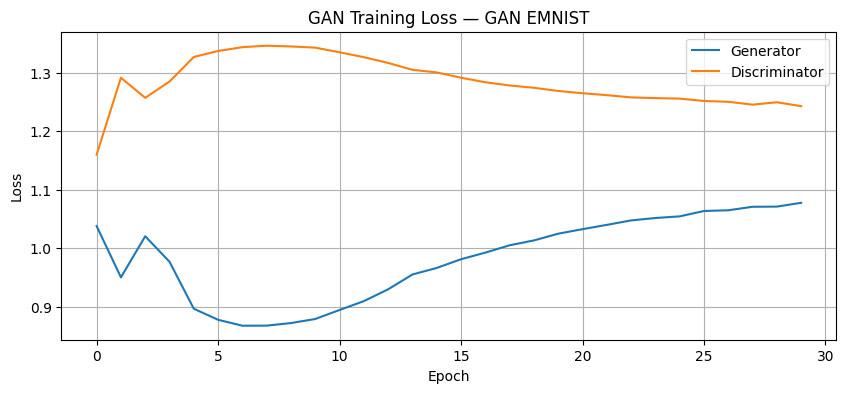

In [36]:
# Train GAN — EMNIST
print('=== Training Vanilla GAN on EMNIST ===')
G_emnist, D_emnist, hist_gan_emnist = train_gan('emnist', noise_dim=100, epochs=30, label='gan')
plot_gan_loss(hist_gan_emnist, 'GAN EMNIST')

In [ ]:
# ============================================================
#  Noise Dimension Study: z in {50, 100, 200}
# ============================================================
print('=== Noise Dimension Study ===')
noise_dims = [50, 100, 200]
noise_results = {}

for nd in noise_dims:
    print(f'--- noise_dim = {nd} ---')
    G_, _, h_ = train_gan('fmnist', noise_dim=nd, epochs=20, label=f'gan_z{nd}')
    noise_results[nd] = {'G': G_, 'history': h_}

plt.figure(figsize=(8,4))
for nd in noise_dims:
    plt.plot(noise_results[nd]['history']['G_loss'], label=f'z={nd}')
plt.xlabel('Epoch'); plt.ylabel('G Loss')
plt.title('Generator Loss vs Noise Dimension')
plt.legend(); plt.grid(True)
plt.savefig(f'{GEN_DIR}/gan_noise_dim_comparison.png', dpi=100)
plt.show()

## 5. Conditional GAN (CGAN)

In [ ]:
# ============================================================
#  CGAN Architecture
# ============================================================

class CGANGenerator(nn.Module):
    def __init__(self, noise_dim=100, num_classes=10, embed_dim=50):
        super().__init__()
        self.embed = nn.Embedding(num_classes, embed_dim)
        in_dim = noise_dim + embed_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),  nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512),     nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 1024),    nn.BatchNorm1d(1024), nn.ReLU(),
            nn.Linear(1024, 784),    nn.Tanh()
        )

    def forward(self, z, labels):
        e = self.embed(labels)
        x = torch.cat([z, e], dim=1)
        return self.net(x).view(-1, 1, 28, 28)


class CGANDiscriminator(nn.Module):
    def __init__(self, num_classes=10, embed_dim=50):
        super().__init__()
        self.embed = nn.Embedding(num_classes, embed_dim)
        in_dim = 784 + embed_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),  nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256),     nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1),       nn.Sigmoid()
        )

    def forward(self, x, labels):
        e  = self.embed(labels)
        xf = x.view(x.size(0), -1)
        return self.net(torch.cat([xf, e], dim=1))


print('CGAN architecture defined.')

In [ ]:
# ============================================================
#  CGAN Training
# ============================================================

def train_cgan(dataset_name='fmnist', noise_dim=100, epochs=50):
    num_classes = FMNIST_CLASSES if dataset_name == 'fmnist' else EMNIST_CLASSES
    loader = loaders[f'{dataset_name}_gan']

    G = CGANGenerator(noise_dim, num_classes).to(DEVICE)
    D = CGANDiscriminator(num_classes).to(DEVICE)

    opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    history = {'G_loss': [], 'D_loss': []}
    best_G  = float('inf')

    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        ep_G = ep_D = 0.0

        for real, labels in tqdm(loader, desc=f'[CGAN-{dataset_name}] Ep {epoch}/{epochs}', leave=False):
            real, labels = real.to(DEVICE), labels.to(DEVICE)
            bs = real.size(0)

            real_lbl = torch.full((bs,1), 0.9, device=DEVICE)
            fake_lbl = torch.zeros(bs, 1, device=DEVICE)

            # D step
            opt_D.zero_grad()
            loss_real = criterion(D(real, labels), real_lbl)
            z    = torch.randn(bs, noise_dim, device=DEVICE)
            fake = G(z, labels).detach()
            loss_fake = criterion(D(fake, labels), fake_lbl)
            d_loss = loss_real + loss_fake
            d_loss.backward(); opt_D.step()

            # G step
            opt_G.zero_grad()
            z    = torch.randn(bs, noise_dim, device=DEVICE)
            fake = G(z, labels)
            g_loss = criterion(D(fake, labels), torch.ones(bs,1,device=DEVICE))
            g_loss.backward(); opt_G.step()

            ep_G += g_loss.item(); ep_D += d_loss.item()

        n = len(loader)
        history['G_loss'].append(ep_G / n)
        history['D_loss'].append(ep_D / n)

        if history['G_loss'][-1] < best_G:
            best_G = history['G_loss'][-1]
            torch.save(G.state_dict(), f'{MODEL_DIR}/cgan_{dataset_name}_G.pt')

        if epoch % 5 == 0:
            # Generate one sample per class
            G.eval()
            with torch.no_grad():
                cls_imgs = []
                for c in range(min(num_classes, 10)):
                    lbl = torch.full((8,), c, dtype=torch.long, device=DEVICE)
                    z_  = torch.randn(8, noise_dim, device=DEVICE)
                    cls_imgs.append(G(z_, lbl).cpu())
                grid = make_grid(torch.cat(cls_imgs), nrow=8,
                                 normalize=True, value_range=(-1,1))
            save_image(grid, f'{GEN_DIR}/cgan_{dataset_name}_ep{epoch:03d}.png')
            print(f'Ep {epoch:3d} | G: {history["G_loss"][-1]:.4f} | D: {history["D_loss"][-1]:.4f}')
            G.train()

    return G, D, history


print('CGAN training function ready.')

In [ ]:
# CGAN helpers

def cgan_class_grid(G, num_classes, noise_dim=100, n_per_class=5, title='CGAN Class Grid'):
    """Generate a grid: rows=classes, cols=samples."""
    G.eval()
    rows = []
    with torch.no_grad():
        for c in range(num_classes):
            lbl = torch.full((n_per_class,), c, dtype=torch.long, device=DEVICE)
            z   = torch.randn(n_per_class, noise_dim, device=DEVICE)
            rows.append(G(z, lbl).cpu())
    grid = make_grid(torch.cat(rows), nrow=n_per_class, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(n_per_class*2, num_classes*2))
    plt.imshow(grid.permute(1,2,0).numpy(), cmap='gray')
    plt.title(title); plt.axis('off')
    plt.savefig(f'{GEN_DIR}/{title.replace(" ","_")}.png', dpi=80, bbox_inches='tight')
    plt.show()


def cgan_label_interpolation(G, num_classes, noise_dim=100, steps=10):
    """Fix z, vary label from 0 to num_classes-1."""
    G.eval()
    z   = torch.randn(1, noise_dim, device=DEVICE).repeat(steps, 1)
    # Pick linearly spaced class labels
    lbls = torch.linspace(0, num_classes-1, steps).long().to(DEVICE)
    with torch.no_grad():
        imgs = G(z, lbls).cpu()
    grid = make_grid(imgs, nrow=steps, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(14,2))
    plt.imshow(grid.permute(1,2,0).numpy(), cmap='gray')
    plt.title('CGAN Label Interpolation (Fixed z, Varying Label)')
    plt.axis('off')
    plt.savefig(f'{GEN_DIR}/cgan_label_interpolation.png', dpi=100, bbox_inches='tight')
    plt.show()

In [ ]:
print('=== Training CGAN on FashionMNIST ===')
cG_fmnist, cD_fmnist, hist_cgan_fmnist = train_cgan('fmnist', epochs=50)
plot_gan_loss(hist_cgan_fmnist, 'CGAN FashionMNIST')
cgan_class_grid(cG_fmnist, FMNIST_CLASSES, title='CGAN FashionMNIST Classes')
cgan_label_interpolation(cG_fmnist, FMNIST_CLASSES)

In [ ]:
print('=== Training CGAN on EMNIST ===')
cG_emnist, cD_emnist, hist_cgan_emnist = train_cgan('emnist', epochs=50)
plot_gan_loss(hist_cgan_emnist, 'CGAN EMNIST')
cgan_class_grid(cG_emnist, EMNIST_CLASSES, title='CGAN EMNIST Classes')

## 6. Deep Convolutional GAN (DCGAN)

In [ ]:
# ============================================================
#  DCGAN Architecture (Radford et al. 2015)
# ============================================================

def weights_init(m):
    """Initialize weights ~ N(0, 0.02) as per Radford et al."""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class DCGANGenerator(nn.Module):
    """
    z (100) -> 7x7x128 -> 14x14x64 -> 28x28x1
    Uses ConvTranspose2d (fractional-stride upsample)
    """
    def __init__(self, noise_dim=100, use_bn=True):
        super().__init__()
        self.use_bn = use_bn
        # Project and reshape to 7x7x128
        self.project = nn.Linear(noise_dim, 7*7*128)
        layers = []
        # 7x7x128 -> 14x14x64
        layers += [nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)]
        if use_bn: layers += [nn.BatchNorm2d(64)]
        layers += [nn.ReLU(True)]
        # 14x14x64 -> 28x28x1
        layers += [nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False)]
        layers += [nn.Tanh()]
        self.main = nn.Sequential(*layers)

    def forward(self, z):
        x = self.project(z).view(-1, 128, 7, 7)
        return self.main(x)


class DCGANDiscriminator(nn.Module):
    """
    28x28x1 -> 14x14x64 -> 7x7x128 -> scalar
    Strided convolutions, no pooling
    """
    def __init__(self, use_bn=True, spectral_norm=False):
        super().__init__()
        def conv_block(in_c, out_c, first=False):
            c = nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)
            if spectral_norm:
                c = nn.utils.spectral_norm(c)
            blk = [c]
            if use_bn and not first:
                blk.append(nn.BatchNorm2d(out_c))
            blk.append(nn.LeakyReLU(0.2, inplace=True))
            return blk

        layers  = conv_block(1,  64,  first=True)   # 28->14
        layers += conv_block(64, 128)                # 14->7
        layers += [nn.Flatten(), nn.Linear(128*7*7, 1), nn.Sigmoid()]
        self.main = nn.Sequential(*layers)

    def forward(self, x):
        return self.main(x)


print('DCGAN architecture defined.')

In [ ]:
# ============================================================
#  DCGAN Training
# ============================================================

def train_dcgan(dataset_name='fmnist', noise_dim=100, epochs=50,
                use_bn=True, spectral_norm=False, label='dcgan'):
    loader = loaders[f'{dataset_name}_gan']
    G = DCGANGenerator(noise_dim, use_bn).to(DEVICE)
    D = DCGANDiscriminator(use_bn, spectral_norm).to(DEVICE)
    G.apply(weights_init); D.apply(weights_init)

    opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    history = {'G_loss': [], 'D_loss': []}
    best_G = float('inf')
    fixed_noise = torch.randn(64, noise_dim, device=DEVICE)

    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        ep_G = ep_D = 0.0

        for real, _ in tqdm(loader, desc=f'[{label.upper()}] Ep {epoch}/{epochs}', leave=False):
            real = real.to(DEVICE)
            bs   = real.size(0)

            real_lbl = torch.full((bs,1), 0.9, device=DEVICE)
            fake_lbl = torch.zeros(bs, 1, device=DEVICE)

            # D
            opt_D.zero_grad()
            d_loss = (criterion(D(real), real_lbl) +
                      criterion(D(G(torch.randn(bs, noise_dim, device=DEVICE)).detach()), fake_lbl))
            d_loss.backward(); opt_D.step()

            # G
            opt_G.zero_grad()
            z = torch.randn(bs, noise_dim, device=DEVICE)
            g_loss = criterion(D(G(z)), torch.ones(bs,1,device=DEVICE))
            g_loss.backward(); opt_G.step()

            ep_G += g_loss.item(); ep_D += d_loss.item()

        n = len(loader)
        history['G_loss'].append(ep_G / n)
        history['D_loss'].append(ep_D / n)

        if history['G_loss'][-1] < best_G:
            best_G = history['G_loss'][-1]
            torch.save(G.state_dict(), f'{MODEL_DIR}/{label}_{dataset_name}_G.pt')

        if epoch % 5 == 0:
            G.eval()
            with torch.no_grad():
                imgs = G(fixed_noise).cpu()
            grid = make_grid(imgs, nrow=8, normalize=True, value_range=(-1,1))
            save_image(grid, f'{GEN_DIR}/{label}_{dataset_name}_ep{epoch:03d}.png')
            print(f'Ep {epoch:3d} | G: {history["G_loss"][-1]:.4f} | D: {history["D_loss"][-1]:.4f}')
            G.train()

    return G, D, history


print('DCGAN training function ready.')

In [ ]:
print('=== Training DCGAN on FashionMNIST ===')
dcG_fmnist, dcD_fmnist, hist_dcgan_fmnist = train_dcgan('fmnist', epochs=50, label='dcgan')
plot_gan_loss(hist_dcgan_fmnist, 'DCGAN FashionMNIST')

In [ ]:
print('=== Training DCGAN on EMNIST ===')
dcG_emnist, dcD_emnist, hist_dcgan_emnist = train_dcgan('emnist', epochs=50, label='dcgan')
plot_gan_loss(hist_dcgan_emnist, 'DCGAN EMNIST')

In [ ]:
# ============================================================
#  Ablation: BatchNorm
# ============================================================
print('=== BatchNorm Ablation Study ===')

ablation_results = {}
for bn_g, bn_d, tag in [(True,True,'both_bn'), (False,True,'no_G_bn'),
                         (True,False,'no_D_bn'), (False,False,'no_bn')]:
    print(f'--- {tag} ---')
    G_, D_, h_ = train_dcgan('fmnist', epochs=20,
                              use_bn=(bn_g and bn_d), label=f'dcgan_{tag}')
    ablation_results[tag] = h_

plt.figure(figsize=(10,4))
for tag, h in ablation_results.items():
    plt.plot(h['G_loss'], label=tag)
plt.xlabel('Epoch'); plt.ylabel('G Loss')
plt.title('DCGAN Ablation: BatchNorm')
plt.legend(); plt.grid(True)
plt.savefig(f'{GEN_DIR}/dcgan_bn_ablation.png', dpi=100)
plt.show()

In [ ]:
# Spectral Normalization comparison
print('=== Spectral Normalization Comparison ===')
_, _, hist_sn = train_dcgan('fmnist', epochs=30, spectral_norm=True, label='dcgan_sn')

plt.figure(figsize=(10,4))
plt.plot(hist_dcgan_fmnist['G_loss'], label='Standard DCGAN')
plt.plot(hist_sn['G_loss'], label='DCGAN + Spectral Norm')
plt.xlabel('Epoch'); plt.ylabel('G Loss')
plt.title('Spectral Normalization Effect')
plt.legend(); plt.grid(True)
plt.savefig(f'{GEN_DIR}/dcgan_spectral_norm_comparison.png', dpi=100)
plt.show()

## 7. Evaluation Metrics

In [ ]:
# ============================================================
#  Evaluation: FID, SSIM, MSE
# ============================================================

from torchmetrics.image.fid import FrechetInceptionDistance
from skimage.metrics import structural_similarity


def compute_fid(real_loader, gen_fn, n_samples=1000):
    """
    Compute FID between real dataset samples and generated images.
    gen_fn: callable() -> Tensor of shape (N,1,28,28) in [-1,1]
    """
    fid = FrechetInceptionDistance(feature=64, normalize=True).to(DEVICE)

    # Real images
    real_collected = []
    for imgs, _ in real_loader:
        real_collected.append(imgs)
        if sum(x.size(0) for x in real_collected) >= n_samples:
            break
    real_imgs = torch.cat(real_collected)[:n_samples]
    # Convert grayscale to RGB (FID expects 3-channel)
    real_rgb = real_imgs.repeat(1,3,1,1).clamp(0,1).to(DEVICE)
    fid.update(real_rgb, real=True)

    # Fake images
    fake_imgs = gen_fn(n_samples)
    # Normalize from [-1,1] or [0,1] to [0,1]
    fake_imgs = ((fake_imgs + 1) / 2).clamp(0,1) if fake_imgs.min() < 0 else fake_imgs.clamp(0,1)
    fake_rgb  = fake_imgs.repeat(1,3,1,1).to(DEVICE)
    fid.update(fake_rgb, real=False)

    return fid.compute().item()


def compute_ssim(model_vae, loader_vae, n=200):
    """Compute average SSIM for VAE reconstructions."""
    model_vae.eval()
    ssims = []
    collected = 0
    for imgs, _ in loader_vae:
        imgs = imgs.to(DEVICE)
        with torch.no_grad():
            recon, _, _ = model_vae(imgs)
        for i in range(imgs.size(0)):
            orig = imgs[i,0].cpu().numpy()
            rec  = recon[i,0].cpu().numpy()
            s    = structural_similarity(orig, rec, data_range=1.0)
            ssims.append(s)
            collected += 1
            if collected >= n:
                break
        if collected >= n:
            break
    return np.mean(ssims)


def compute_recon_mse(model_vae, loader_vae, n=500):
    """Compute average reconstruction MSE."""
    model_vae.eval()
    mses, total = 0.0, 0
    for imgs, _ in loader_vae:
        imgs = imgs.to(DEVICE)
        with torch.no_grad():
            recon, _, _ = model_vae(imgs)
        mses += F.mse_loss(recon, imgs, reduction='sum').item()
        total += imgs.numel()
        if total // imgs[0].numel() >= n:
            break
    return mses / total


print('Evaluation metric functions defined.')

In [ ]:
# ============================================================
#  Compute Metrics — FashionMNIST
# ============================================================
print('Computing evaluation metrics for FashionMNIST...')

# VAE
vae_ssim  = compute_ssim(vae_fmnist, loaders['fmnist_vae'])
vae_mse   = compute_recon_mse(vae_fmnist, loaders['fmnist_vae'])

def gen_vae(n):   return vae_fmnist.sample(n).cpu()
def gen_gan(n):   
    G_fmnist.eval()
    with torch.no_grad():
        return G_fmnist(torch.randn(n, 100, device=DEVICE)).cpu()
def gen_cgan(n):  
    cG_fmnist.eval()
    with torch.no_grad():
        lbls = torch.randint(0, FMNIST_CLASSES, (n,), device=DEVICE)
        return cG_fmnist(torch.randn(n, 100, device=DEVICE), lbls).cpu()
def gen_dcgan(n): 
    dcG_fmnist.eval()
    with torch.no_grad():
        return dcG_fmnist(torch.randn(n, 100, device=DEVICE)).cpu()

fid_vae   = compute_fid(loaders['fmnist_vae'],  gen_vae)
fid_gan   = compute_fid(loaders['fmnist_gan'],  gen_gan)
fid_cgan  = compute_fid(loaders['fmnist_gan'],  gen_cgan)
fid_dcgan = compute_fid(loaders['fmnist_gan'],  gen_dcgan)

print(f'FashionMNIST FID  -> VAE: {fid_vae:.2f} | GAN: {fid_gan:.2f} | CGAN: {fid_cgan:.2f} | DCGAN: {fid_dcgan:.2f}')
print(f'VAE SSIM: {vae_ssim:.4f} | VAE MSE: {vae_mse:.6f}')

## 8. Comparison Table

In [ ]:
# ============================================================
#  Comparison Table
# ============================================================
import pandas as pd

# Timing estimates from training cells above (manually fill if needed)
comparison_data = {
    'Model':   ['VAE', 'GAN', 'CGAN', 'DCGAN'],
    'Dataset': ['FashionMNIST']*4,
    'FID ↓':   [round(fid_vae,2), round(fid_gan,2), round(fid_cgan,2), round(fid_dcgan,2)],
    'Recon MSE ↓': [round(vae_mse,6), 'N/A', 'N/A', 'N/A'],
    'SSIM ↑':  [round(vae_ssim,4), 'N/A', 'N/A', 'N/A'],
    'Epochs':  [30, 50, 50, 50],
    'Architecture': ['Encoder-Decoder', 'FC G+D', 'Conditional FC G+D', 'Conv G+D'],
    'Class Control': ['Partial (CVAE)', 'None', 'Full', 'None'],
    'Stability': ['High', 'Low', 'Medium', 'Medium-High'],
    'Sharpness': ['Blurry', 'Sharp', 'Sharp+Ctrl', 'Sharpest'],
}

df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))
df.to_csv(f'{WORK_DIR}/comparison_table.csv', index=False)
print('\nComparison table saved.')

## 9. Data Augmentation with Generative Models

In [ ]:
# ============================================================
#  Simple CNN Classifier (LeNet-like)
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def train_classifier(train_loader, val_loader, num_classes=10, epochs=20, tag=''):
    model = SimpleCNN(num_classes).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=1e-3)
    sched = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)
    crit  = nn.CrossEntropyLoss()
    best_acc, best_state = 0.0, None

    for epoch in range(1, epochs+1):
        model.train()
        for imgs, labels in tqdm(train_loader, desc=f'[Clf{tag}] Ep {epoch}/{epochs}', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(imgs), labels)
            loss.backward(); opt.step()
        sched.step()

        # Validate
        model.eval(); correct = total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                preds = model(imgs.to(DEVICE)).argmax(1).cpu()
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        acc = correct / total
        if acc > best_acc:
            best_acc = acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    print(f'Best Val Acc [{tag}]: {best_acc*100:.2f}%')
    return model, best_acc


print('Classifier defined.')

In [ ]:
# ============================================================
#  Augmentation Experiment
# ============================================================

# 10% of FashionMNIST training data
n_10pct = int(0.1 * len(fmnist_train_vae))
indices = torch.randperm(len(fmnist_train_vae))[:n_10pct]
subset_10pct = Subset(fmnist_train_vae, indices)

loader_10pct = DataLoader(subset_10pct, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(fmnist_test_vae, batch_size=256, shuffle=False, num_workers=2)

# Baseline: train on 10% real data
print('=== Baseline Classifier (10% real data) ===')
clf_baseline, acc_baseline = train_classifier(loader_10pct, test_loader, tag='baseline')

print(f'Baseline Test Accuracy: {acc_baseline*100:.2f}%')

In [ ]:
# ============================================================
#  Generate synthetic images from CGAN for augmentation
# ============================================================

class SyntheticDataset(torch.utils.data.Dataset):
    """Wrap generated images as a PyTorch Dataset."""
    def __init__(self, images, labels):
        # images: Tensor [N,1,28,28] in [-1,1], convert to [0,1]
        self.images = ((images + 1) / 2).clamp(0,1)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


# Generate synthetic images
n_synthetic = n_10pct  # 50/50 split
cG_fmnist.eval()
syn_imgs_list, syn_lbls_list = [], []
per_class = n_synthetic // FMNIST_CLASSES

with torch.no_grad():
    for c in range(FMNIST_CLASSES):
        lbl = torch.full((per_class,), c, dtype=torch.long, device=DEVICE)
        z   = torch.randn(per_class, 100, device=DEVICE)
        syn_imgs_list.append(cG_fmnist(z, lbl).cpu())
        syn_lbls_list.append(lbl.cpu())

syn_imgs = torch.cat(syn_imgs_list)
syn_lbls = torch.cat(syn_lbls_list)

synthetic_ds = SyntheticDataset(syn_imgs, syn_lbls)
augmented_ds = ConcatDataset([subset_10pct, synthetic_ds])
aug_loader   = DataLoader(augmented_ds, batch_size=128, shuffle=True, num_workers=2)

print(f'Augmented dataset size: {len(augmented_ds)} (real: {n_10pct}, synthetic: {len(synthetic_ds)})')

In [ ]:
# Train on augmented data
print('=== Augmented Classifier (50% real + 50% CGAN synthetic) ===')
clf_augmented, acc_augmented = train_classifier(aug_loader, test_loader, tag='augmented')

print(f'\n--- Data Augmentation Results ---')
print(f'Baseline (10% real):   {acc_baseline*100:.2f}%')
print(f'Augmented (10%+CGAN):  {acc_augmented*100:.2f}%')
print(f'Improvement:           +{(acc_augmented-acc_baseline)*100:.2f}%')

## 10. GAN Variants Analysis

In [ ]:
# ============================================================
#  GAN Variants: WGAN, WGAN-GP, LSGAN, Non-Saturating
# ============================================================

# --- WGAN ---
class WGANGenerator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256), nn.LeakyReLU(0.2), nn.BatchNorm1d(256),
            nn.Linear(256, 512),       nn.LeakyReLU(0.2), nn.BatchNorm1d(512),
            nn.Linear(512, 1024),      nn.LeakyReLU(0.2), nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),      nn.Tanh()
        )
    def forward(self, z):
        return self.net(z).view(-1,1,28,28)

class WGANCritic(nn.Module):  # No sigmoid — outputs raw score
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),  nn.LeakyReLU(0.2),
            nn.Linear(512, 256),  nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


def compute_gradient_penalty(critic, real, fake):
    """WGAN-GP gradient penalty."""
    alpha = torch.rand(real.size(0), 1, 1, 1, device=DEVICE)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp = critic(interpolated)
    grads = torch.autograd.grad(d_interp, interpolated,
                                grad_outputs=torch.ones_like(d_interp),
                                create_graph=True, retain_graph=True)[0]
    return ((grads.norm(2, dim=[1,2,3]) - 1) ** 2).mean()


def train_wgan(dataset_name='fmnist', noise_dim=100, epochs=50,
               gp=False, clip_value=0.01, lambda_gp=10, label='wgan'):
    loader = loaders[f'{dataset_name}_gan']
    G = WGANGenerator(noise_dim).to(DEVICE)
    C = WGANCritic().to(DEVICE)
    opt_G = optim.RMSprop(G.parameters(), lr=5e-5)
    opt_C = optim.RMSprop(C.parameters(), lr=5e-5)

    history = {'G_loss': [], 'D_loss': []}
    n_critic = 5  # Train critic n_critic times per G step

    for epoch in range(1, epochs+1):
        G.train(); C.train()
        ep_G = ep_C = 0.0
        loader_iter = cycle(iter(loader))

        for _ in tqdm(range(len(loader)), desc=f'[{label.upper()}] Ep {epoch}/{epochs}', leave=False):
            # Critic steps
            for _ in range(n_critic):
                real, _ = next(loader_iter)
                real = real.to(DEVICE)
                bs   = real.size(0)
                z    = torch.randn(bs, noise_dim, device=DEVICE)
                fake = G(z).detach()
                opt_C.zero_grad()
                c_loss = -C(real).mean() + C(fake).mean()
                if gp:
                    c_loss += lambda_gp * compute_gradient_penalty(C, real, fake)
                c_loss.backward()
                opt_C.step()
                if not gp:  # Weight clipping for standard WGAN
                    for p in C.parameters():
                        p.data.clamp_(-clip_value, clip_value)
                ep_C += c_loss.item()

            # Generator step
            real, _ = next(loader_iter)
            bs = real.size(0)
            z  = torch.randn(bs, noise_dim, device=DEVICE)
            opt_G.zero_grad()
            g_loss = -C(G(z)).mean()
            g_loss.backward()
            opt_G.step()
            ep_G += g_loss.item()

        n = len(loader)
        history['G_loss'].append(ep_G / n)
        history['D_loss'].append(ep_C / (n * n_critic))

        if epoch % 10 == 0:
            print(f'Ep {epoch:3d} | G: {history["G_loss"][-1]:.4f} | C: {history["D_loss"][-1]:.4f}')

    return G, C, history


def train_lsgan(dataset_name='fmnist', noise_dim=100, epochs=50):
    """Least Squares GAN — MSE loss instead of BCE."""
    loader = loaders[f'{dataset_name}_gan']
    G = GANGenerator(noise_dim).to(DEVICE)
    D = GANDiscriminator().to(DEVICE)  # Keep Sigmoid for stability
    opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
    opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

    history = {'G_loss': [], 'D_loss': []}

    for epoch in range(1, epochs+1):
        G.train(); D.train()
        ep_G = ep_D = 0.0

        for real, _ in tqdm(loader, desc=f'[LSGAN] Ep {epoch}/{epochs}', leave=False):
            real = real.to(DEVICE)
            bs   = real.size(0)
            z    = torch.randn(bs, noise_dim, device=DEVICE)
            fake = G(z).detach()

            # D: LS loss — (D(x)-1)^2 + D(G(z))^2
            opt_D.zero_grad()
            d_loss = 0.5 * (((D(real) - 1)**2).mean() + (D(fake)**2).mean())
            d_loss.backward(); opt_D.step()

            # G: (D(G(z))-1)^2
            opt_G.zero_grad()
            z = torch.randn(bs, noise_dim, device=DEVICE)
            g_loss = 0.5 * ((D(G(z)) - 1)**2).mean()
            g_loss.backward(); opt_G.step()

            ep_G += g_loss.item(); ep_D += d_loss.item()

        n = len(loader)
        history['G_loss'].append(ep_G/n)
        history['D_loss'].append(ep_D/n)

        if epoch % 10 == 0:
            print(f'Ep {epoch:3d} | G: {history["G_loss"][-1]:.4f} | D: {history["D_loss"][-1]:.4f}')

    return G, D, history


print('GAN variant training functions ready.')

In [ ]:
# Train all GAN variants on FashionMNIST
VARIANT_EPOCHS = 30

print('=== Non-Saturating GAN ===')
_, _, hist_ns = train_gan('fmnist', epochs=VARIANT_EPOCHS, non_saturating=True, label='nsg')

print('=== WGAN (weight clipping) ===')
_, _, hist_wgan = train_wgan('fmnist', epochs=VARIANT_EPOCHS, gp=False, label='wgan')

print('=== WGAN-GP ===')
_, _, hist_wgangp = train_wgan('fmnist', epochs=VARIANT_EPOCHS, gp=True, label='wgangp')

print('=== LSGAN ===')
_, _, hist_ls = train_lsgan('fmnist', epochs=VARIANT_EPOCHS)

In [ ]:
# ============================================================
#  Plot GAN Variant Loss Curves
# ============================================================

variants = {
    'Vanilla GAN':     hist_gan_fmnist,
    'Non-Saturating':  hist_ns,
    'WGAN':            hist_wgan,
    'WGAN-GP':         hist_wgangp,
    'LSGAN':           hist_ls,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in variants.items():
    axes[0].plot(h['G_loss'], label=name)
    axes[1].plot(h['D_loss'], label=name)

axes[0].set_title('Generator Loss — All Variants')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].set_title('Discriminator/Critic Loss — All Variants')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('GAN Variant Comparison — FashionMNIST', fontsize=14)
plt.tight_layout()
plt.savefig(f'{GEN_DIR}/gan_variants_loss.png', dpi=100, bbox_inches='tight')
plt.show()
print('GAN variant comparison plot saved.')

## 11. Final Results Summary

In [ ]:
# ============================================================
#  Show Final Generated Images Side-by-Side
# ============================================================

def show_generated_grid(G, title, noise_dim=100, n=64, cgan=False,
                         num_classes=10, is_vae=False):
    G.eval()
    with torch.no_grad():
        if is_vae:
            imgs = G.sample(n).cpu()
            imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())  # [0,1]
        elif cgan:
            lbls = torch.randint(0, num_classes, (n,), device=DEVICE)
            z    = torch.randn(n, noise_dim, device=DEVICE)
            imgs = G(z, lbls).cpu()
        else:
            z    = torch.randn(n, noise_dim, device=DEVICE)
            imgs = G(z).cpu()

    vr = (0,1) if is_vae else (-1,1)
    grid = make_grid(imgs, nrow=8, normalize=True, value_range=vr)
    plt.figure(figsize=(10,10))
    plt.imshow(grid.permute(1,2,0).numpy(), cmap='gray')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.savefig(f'{GEN_DIR}/final_{title.replace(" ","_")}.png', dpi=100, bbox_inches='tight')
    plt.show()


print('=== Final Generated Images — FashionMNIST ===')
show_generated_grid(vae_fmnist,  'VAE FashionMNIST',   is_vae=True)
show_generated_grid(G_fmnist,    'GAN FashionMNIST')
show_generated_grid(cG_fmnist,   'CGAN FashionMNIST',  cgan=True, num_classes=FMNIST_CLASSES)
show_generated_grid(dcG_fmnist,  'DCGAN FashionMNIST')

print('=== Final Generated Images — EMNIST ===')
show_generated_grid(vae_emnist,  'VAE EMNIST',   is_vae=True)
show_generated_grid(G_emnist,    'GAN EMNIST')
show_generated_grid(cG_emnist,   'CGAN EMNIST',  cgan=True, num_classes=EMNIST_CLASSES)
show_generated_grid(dcG_emnist,  'DCGAN EMNIST')

In [ ]:
# ============================================================
#  Print Final Summary
# ============================================================

print('=' * 60)
print('           FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'\n[FashionMNIST]')
print(f'  VAE   - FID: {fid_vae:.2f}  | SSIM: {vae_ssim:.4f} | MSE: {vae_mse:.6f}')
print(f'  GAN   - FID: {fid_gan:.2f}')
print(f'  CGAN  - FID: {fid_cgan:.2f}')
print(f'  DCGAN - FID: {fid_dcgan:.2f}')
print(f'\n[Data Augmentation]')
print(f'  Baseline (10% real):   {acc_baseline*100:.2f}%')
print(f'  Augmented (+ CGAN):    {acc_augmented*100:.2f}%')
print(f'  Improvement:           +{(acc_augmented-acc_baseline)*100:.2f}%')
print(f'\n[GAN Variants - FashionMNIST final G loss]')
for name, h in variants.items():
    print(f'  {name:20s}: {h["G_loss"][-1]:.4f}')
print('=' * 60)
print(f'\nAll outputs saved to: {GEN_DIR}')
print(f'All models saved to:  {MODEL_DIR}')
print(f'Comparison table:     {WORK_DIR}/comparison_table.csv')